# 📊 Estudo de Caso: Desempenho de Alunos

Você foi contratado como cientista de dados para analisar o desempenho de uma turma.
Seu objetivo é gerar insights para melhorar o ensino.

Utilizando o material e as métricas apresentadas na aula de hoje, apresente seus _insigths_ para o _dataset_ apresentado:

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_estudo_estatistica.csv')
df.head()

,horas_estudo,acessos_plataforma,faltas,tempo_resolucao,bolsa_estagio,turno,linguagem,nota
0,7,39,10,167,1,Manhã,Java,75.596400
1,4,39,9,183,1,Manhã,Java,0.000000
2,8,37,6,166,0,Manhã,C,66.178579
3,5,9,11,109,0,Noite,Python,35.059806
4,7,110,8,166,1,Noite,C,57.371902


In [64]:
df_encoded = pd.get_dummies(df, columns=['turno','linguagem'], dtype=int)
df_encoded.head()

,horas_estudo,acessos_plataforma,faltas,tempo_resolucao,bolsa_estagio,nota,turno_Manhã,turno_Noite,linguagem_C,linguagem_Java,linguagem_Python
0,7,39,10,167,1,75.596400,1,0,0,1,0
1,4,39,9,183,1,0.000000,1,0,0,1,0
2,8,37,6,166,0,66.178579,1,0,1,0,0
3,5,9,11,109,0,35.059806,0,1,0,0,1
4,7,110,8,166,1,57.371902,0,1,1,0,0


## Exercício 1
Obtendo um boxplot do dataframe trabalhado para observar se há valores extremos - outliers.

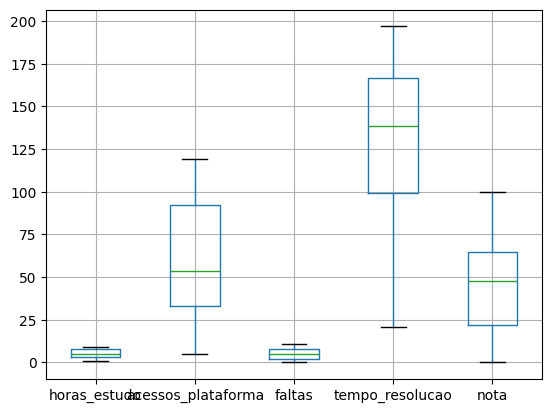

<Figure size 2000x2000 with 0 Axes>

In [3]:
df.boxplot(column=['horas_estudo','acessos_plataforma','faltas','tempo_resolucao','nota'])
plt.figure(figsize=(20,20))
plt.show()

Não há valores extremos que possam afetar a análise da média de cada parâmetro.

## Exercício 2
Média de horas de estudo da turma

In [89]:
media_horas = df['horas_estudo'].mean()
desvio_horas = df['horas_estudo'].std()
print(f'Média de horas de estudo: {media_horas}')
print(f'Desvio padrão de horas de estudo: {desvio_horas}')

Média de horas de estudo: 5.3625
Desvio padrão de horas de estudo: 2.615647897567758


## Exercício 3
Média de acessos à plataforma de estudos

In [92]:
media_acessos = df['acessos_plataforma'].mean()
desvio_acessos = df['acessos_plataforma'].std()
print(f'Média de acessos: {media_acessos}')
print(f'Desvio padrão: {desvio_acessos}')

Média de acessos: 59.95
Desvio padrão: 33.920196739338685


## Exercício 4
Média do tempo de resolução de exercícios (ou provas) da turma

In [93]:
media_tr = df['tempo_resolucao'].mean()
desvio_tr = df['tempo_resolucao'].std()
print(f'Média de tempo de resolução: {media_tr}')
print(f'Desvio padrão: {desvio_tr}')

Média de tempo de resolução: 128.4125
Desvio padrão: 48.33498451275328


## Exercício 5
Média de notas da turma. É observado um desempenho abaixo da média - 44.6/100

In [94]:
media_notas = df['nota'].mean()
desvio_notas = df['nota'].std()
print(f'Média de notas: {media_notas}')
print(f'Desvio padrão: {desvio_notas}')

Média de notas: 44.63521894022
Desvio padrão: 27.985507442917005


## Exercício 6
Moda - há mais alunos em qual turno?

In [65]:
df['turno'].mode()

,turno
0,Noite


## Exercício 7
Moda - Qual linguagem é mais utilizada pelos alunos?

In [66]:
df['linguagem'].mode()

,linguagem
0,Java


## Exercício 8
Média de notas e horas de estudo de quem estuda a linguagem Java

In [104]:
media_horas_java = df_encoded[df_encoded['linguagem_Java'] == 1].groupby('linguagem_Java')['horas_estudo'].mean()
print(media_horas_java)
media_notas_java = df_encoded[df_encoded['linguagem_Java'] == 1].groupby('linguagem_Java')['nota'].mean()
print(media_notas_java)

linguagem_Java
1    5.096774
Name: horas_estudo, dtype: float64
linguagem_Java
1    40.35317
Name: nota, dtype: float64


## Exercício 9
Média de notas e horas de estudo de quem estuda a linguagem C

In [108]:
media_horas_c = df_encoded[df_encoded['linguagem_C'] == 1].groupby('linguagem_C')['horas_estudo'].mean()
print(media_horas_c)
media_notas_c = df_encoded[df_encoded['linguagem_C'] == 1].groupby('linguagem_C')['nota'].mean()
print(media_notas_c)

linguagem_C
1    5.35
Name: horas_estudo, dtype: float64
linguagem_C
1    47.281207
Name: nota, dtype: float64


## Exercício 10
Média de notas e horas de estudo de quem estuda a linguagem Python

In [110]:
media_horas_py = df_encoded[df_encoded['linguagem_Python'] == 1].groupby('linguagem_Python')['horas_estudo'].mean()
print(media_horas_py)
media_notas_py = df_encoded[df_encoded['linguagem_Python'] == 1].groupby('linguagem_Python')['nota'].mean()
print(media_notas_py)

linguagem_Python
1    5.655172
Name: horas_estudo, dtype: float64
linguagem_Python
1    47.387763
Name: nota, dtype: float64


## Exercício 11
Correlação entre número de faltas e nota - não há

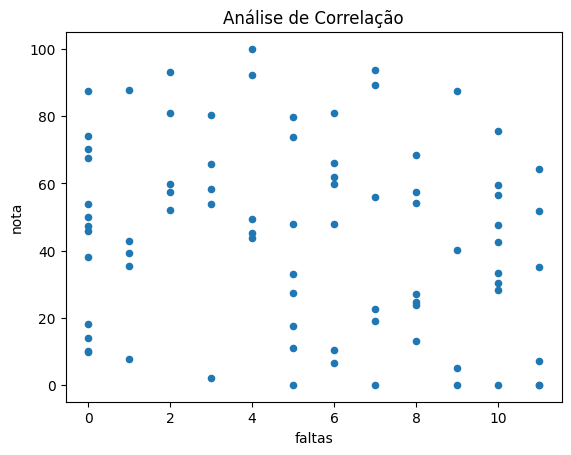

-0.14007793949003985


In [88]:
df.plot(kind='scatter', x='faltas', y='nota', title='Análise de Correlação')
plt.show()
correlacao = df['acessos_plataforma'].corr(df['nota'])
print(correlacao)

## Exercício 12
Correlação entre acessos à plataforma e nota - não há

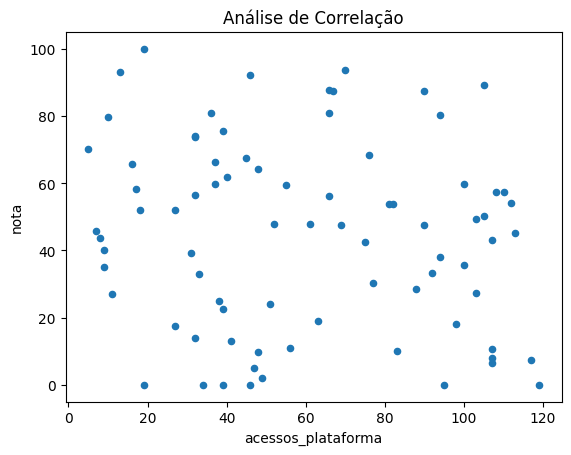

-0.14007793949003985


In [42]:
df.plot(kind='scatter', x='acessos_plataforma', y='nota', title='Análise de Correlação')
plt.show()
correlacao = df['acessos_plataforma'].corr(df['nota'])
print(correlacao)

## Exercício 13
Correlação entre horas de estudo e e tempo de resolução

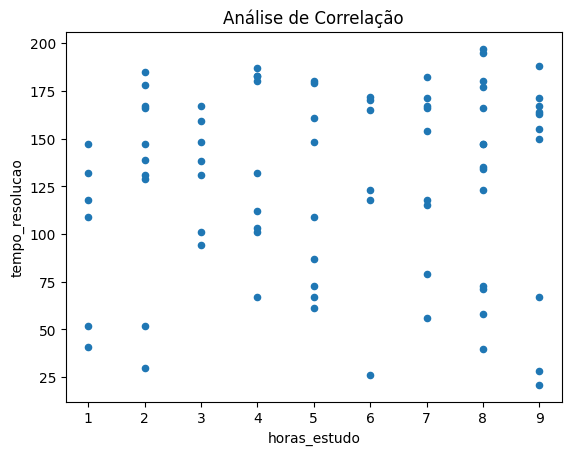

0.05997718156905909


In [30]:
df.plot(kind='scatter', x='horas_estudo', y='tempo_resolucao', title='Análise de Correlação')
plt.show()
correlacao = df['horas_estudo'].corr(df['tempo_resolucao'])
print(correlacao)

## Exercício 14
Correlação entre faltas e nota

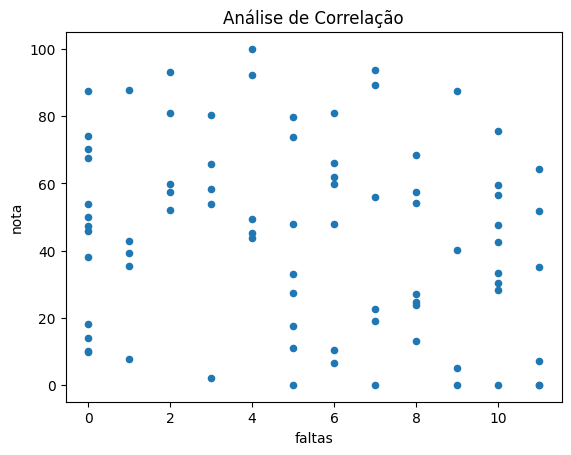

-0.19672431514472116


In [98]:
df.plot(kind='scatter', x='faltas', y='nota', title='Análise de Correlação')
plt.show()
correlacao = df['faltas'].corr(df['nota'])
print(correlacao)

## Exercício 15
Correlação entre tempo de resolução e notas - não há

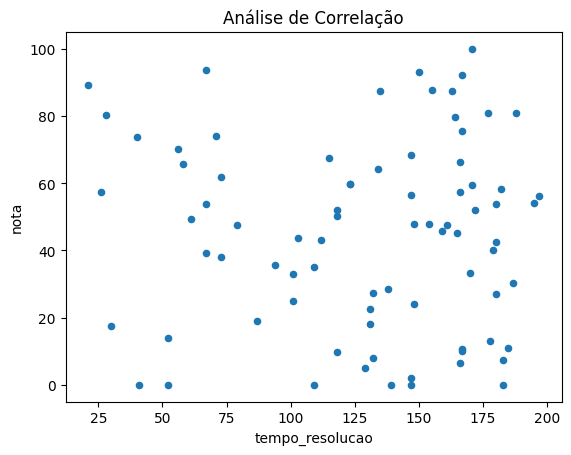

-0.030751054744315207


In [28]:
df.plot(kind='scatter', x='tempo_resolucao', y='nota', title='Análise de Correlação')
plt.show()
correlacao = df['tempo_resolucao'].corr(df['nota'])
print(correlacao)

## Exercício 16
Correlação entre horas de estudo e o tempo de resolução - não há

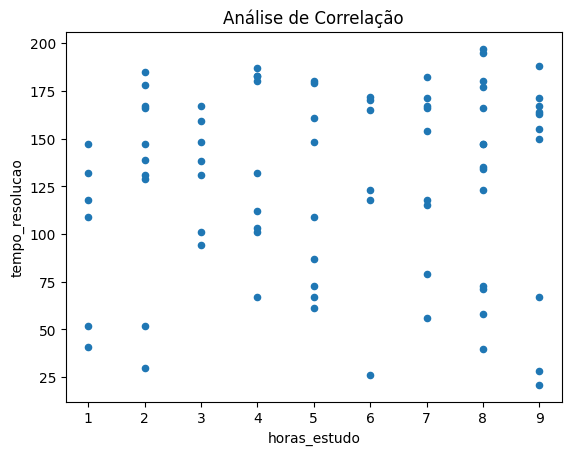

0.05997718156905909


In [45]:
df.plot(kind='scatter', x='horas_estudo', y='tempo_resolucao', title='Análise de Correlação')
plt.show()
correlacao = df['horas_estudo'].corr(df['tempo_resolucao'])
print(correlacao)

## Exercício 17
Correlação entre horas de estudo e nota. <br> Há uma correlação positiva.

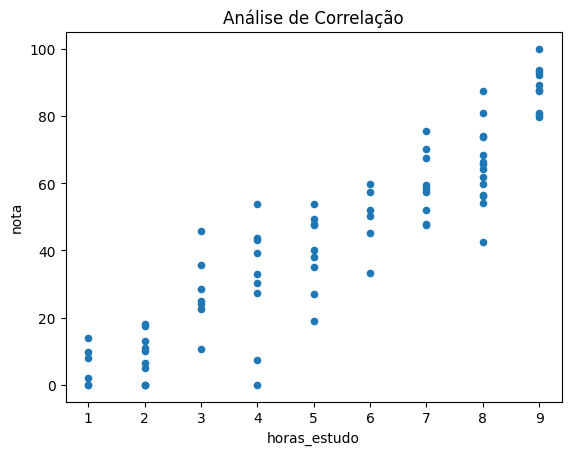

0.9180856640311844


In [36]:
df.plot(kind='scatter', x='horas_estudo', y='nota', title='Análise de Correlação')
plt.show()
correlacao = df['horas_estudo'].corr(df['nota'])
print(correlacao)

## Exercício 18
Media de faltas por turno:

In [116]:
media_faltas_turnoM = df_encoded[df_encoded['turno_Manhã'] == 1].groupby('turno_Manhã')['faltas'].mean()
print(media_faltas_turnoM)
dp_faltas_turnoM = df_encoded[df_encoded['turno_Manhã'] == 1].groupby('turno_Manhã')['faltas'].std()
print(dp_faltas_turnoM)

turno_Manhã
1    4.6
Name: faltas, dtype: float64
turno_Manhã
1    3.647723
Name: faltas, dtype: float64


In [117]:
media_faltas_turnoN = df_encoded[df_encoded['turno_Noite'] == 1].groupby('turno_Noite')['faltas'].mean()
print(media_faltas_turnoN)
dp_faltas_turnoN = df_encoded[df_encoded['turno_Noite'] == 1].groupby('turno_Noite')['faltas'].std()
print(dp_faltas_turnoN)

turno_Noite
1    5.8
Name: faltas, dtype: float64
turno_Noite
1    3.653143
Name: faltas, dtype: float64


## Exercício 19
Quais as 10 maiores notas de cada turno:


In [111]:
maiores_notas_turnoM = df_encoded[df_encoded['turno_Manhã'] == 1].groupby('turno_Manhã')['nota'].nlargest(10)
print(maiores_notas_turnoM)
maiores_notas_turnoN = df_encoded[df_encoded['turno_Noite'] == 1].groupby('turno_Noite')['nota'].nlargest(10)
print(maiores_notas_turnoN)

turno_Manhã    
1            39    100.000000
             37     93.141884
             68     92.291915
             44     87.489438
             22     87.331979
             72     79.777842
             0      75.596400
             31     70.252046
             10     68.284186
             6      67.502533
Name: nota, dtype: float64
turno_Noite    
1            67    93.704275
             27    89.185322
             70    87.771806
             79    80.820541
             61    80.784599
             33    80.276799
             7     74.083989
             66    73.730891
             11    65.685085
             76    64.232158
Name: nota, dtype: float64


## Exercício 20
Média de horas de estudo e notas por turno:

In [113]:
media_horas_turnoM = df_encoded[df_encoded['turno_Manhã'] == 1].groupby('turno_Manhã')['horas_estudo'].mean()
print(media_horas_turnoM)
media_notas_turnoM = df_encoded[df_encoded['turno_Manhã'] == 1].groupby('turno_Manhã')['nota'].mean()
print(media_notas_turnoM)
media_horas_turnoN = df_encoded[df_encoded['turno_Noite'] == 1].groupby('turno_Noite')['horas_estudo'].mean()
print(media_horas_turnoN)
media_notas_turnoN = df_encoded[df_encoded['turno_Noite'] == 1].groupby('turno_Noite')['nota'].mean()
print(media_notas_turnoN)

turno_Manhã
1    5.428571
Name: horas_estudo, dtype: float64
turno_Manhã
1    47.302129
Name: nota, dtype: float64
turno_Noite
1    5.311111
Name: horas_estudo, dtype: float64
turno_Noite
1    42.560956
Name: nota, dtype: float64


Ambos os turnos têm médias de horas de estudo similares - o turno da manhã tem tempo médio de estudo levemente superior ao turno da noite. Esses fatores possuem uma correlação positiva, portanto, a média de notas do turno da manhã é melhor.